# ELEN4025 — Individual Project 2026
## Predicting Student Outcomes for the OULAD database.

In [70]:
# IMPORT LIBRARIES
import os, warnings
import numpy as np           
import pandas as pd         
import matplotlib.pyplot as plt        
import matplotlib.gridspec as gridspec 
import seaborn as sns                   
from sklearn.linear_model    import SGDClassifier     
from sklearn.preprocessing   import StandardScaler     
from sklearn.pipeline        import Pipeline           
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,  
    roc_curve, roc_auc_score,                 
    classification_report, accuracy_score,    
    precision_score, recall_score, f1_score   
)

warnings.filterwarnings('ignore')  
SEED = 42                          
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded OK')

Libraries loaded OK


In [5]:
# LOAD THE OULAD DATA FILES
# FILES:
#   studentInfo.csv     
#   studentVle.csv      
#   vle.csv             
#   assessments.csv    
#   studentAssessment.csv

DATA_DIR = '.'  

def load(fn):
    """Helper: load a CSV and print its shape so we know it worked."""
    path = os.path.join(DATA_DIR, fn)
    df = pd.read_csv(
        path,
        encoding='latin-1',   
        on_bad_lines='skip',  
        low_memory=False      
    )
    print(f'  {fn:35s}  shape={df.shape}')
    return df

print('Loading CSVs...')
info     = load('studentInfo.csv')   
vle_df   = load('studentVle.csv')    
vle_meta = load('vle.csv')           
try:
    assessments = load('assessments.csv')
    stu_assess  = load('studentAssessment.csv')
    USE_ASSESS  = True
    print('  Assessment files loaded OK')
except FileNotFoundError:
    USE_ASSESS = False
    print('  Assessment files not found — skipping (this is fine)')

print('Done.')

Loading CSVs...
  studentInfo.csv                      shape=(32593, 12)
  studentVle.csv                       shape=(10655280, 6)
  vle.csv                              shape=(6364, 6)
  assessments.csv                      shape=(206, 6)
  studentAssessment.csv                shape=(173912, 5)
  Assessment files loaded OK
Done.


In [130]:
# TARGET VARIABLE + LEAKAGE PREVENTION
#Target:
# We want to predict whether a student will FAIL or PASS based on their first
# 4 weeks of activity. The original 'final_result' column has 4 values:
#   Pass, Distinction, Fail, Withdrawn
# We collapse this to binary: 0 = good outcome (Pass/Distinction)
#                             1 = bad outcome  (Fail/Withdrawn)
# Leakage:
#   1. Only keep VLE clicks with date <= 28
#   2. 'final_result' is turned into the target immediately and NEVER used as a feature
#   3. The StandardScaler is fitted ONLY on training data

WEEK4_CUTOFF = 28  # 4 weeks x 7 days per week = day 28

# Keep only VLE rows that happened on or before day 28
vle_w4 = vle_df[vle_df['date'] <= WEEK4_CUTOFF].copy()
print(f'VLE rows BEFORE week-4 cutoff : {len(vle_df):>10,}')
print(f'VLE rows AFTER  week-4 cutoff : {len(vle_w4):>10,}  ({len(vle_w4)/len(vle_df):.1%} retained)')

# Convert final_result into a binary target (0 = pass, 1 = fail)
# We do this first so the raw 'final_result' text column is never used as a feature
info['target'] = info['final_result'].apply(
    lambda x: 0 if x in ['Pass', 'Distinction'] else 1
)
vc = info['target'].value_counts()
print(f'\nClass balance:')
print(f'  0  Pass/Distinction : {vc[0]:,}  ({vc[0]/len(info):.1%})')
print(f'  1  Fail/Withdrawn   : {vc[1]:,}  ({vc[1]/len(info):.1%})')

VLE rows BEFORE week-4 cutoff : 10,655,280
VLE rows AFTER  week-4 cutoff :  2,847,851  (26.7% retained)

Class balance:
  0  Pass/Distinction : 15,385  (47.2%)
  1  Fail/Withdrawn   : 17,208  (52.8%)


In [132]:
# FEATURE ENGINEERING
# We create TWO groups of features:
#   A) DEMOGRAPHIC features  - who the student is (age, education, etc.)
#   B) VLE ENGAGEMENT features - how much the student interacted online in Week 1-4

grp = ['id_student', 'code_module', 'code_presentation']  # unique ID per student-enrolment

# Demographic features (from studentInfo.csv)
# These are known at enrolment time — no leakage risk.
demo_cols = grp + [
    'gender', 'region', 'highest_education', 'imd_band',   
    'age_band', 'num_of_prev_attempts', 'studied_credits', 
    'disability', 'target'                                
]
demo = info[demo_cols].copy()

# VLE engagement features (from studentVle.csv + vle.csv, week <= 4 only)

# First, attach the activity type (e.g. 'quiz', 'resource', 'forumng') to each click row
vle_w4_meta = vle_w4.merge(vle_meta[['id_site','activity_type']], on='id_site', how='left')

# Feature 1: Total clicks — how many times did the student click ANYTHING in Week 1-4?
# A student who barely clicked is likely less engaged and more at risk.
total_clicks = (vle_w4_meta.groupby(grp)['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'total_clicks_w4'}))

# Feature 2: Active days — on how many distinct days did the student log in?
# Consistent daily engagement is a better sign than one big session.
active_days = (vle_w4_meta.groupby(grp)['date']
    .nunique().reset_index().rename(columns={'date':'active_days_w4'}))

# Feature 3: Resource type diversity — how many different TYPES of resources did they use?
# Engaging with quizzes, readings, AND forums suggests deeper learning.
resource_types = (vle_w4_meta.groupby(grp)['activity_type']
    .nunique().reset_index().rename(columns={'activity_type':'n_resource_types_w4'}))

# Feature 4: Clicks per activity type (wide/pivot format)
# This creates one column per resource type (e.g. clicks_quiz_w4, clicks_resource_w4) so the model can see WHERE the engagement happened, not just total volume.
activity_pivot = (vle_w4_meta.groupby(grp+['activity_type'])['sum_click']
    .sum().unstack(fill_value=0).reset_index())
act_cols = [c for c in activity_pivot.columns if c not in grp]
activity_pivot.columns = grp + [f'clicks_{c}_w4' for c in act_cols]

# Feature 5: Average clicks per active day — intensity of engagement per session
# A student who logs in 10 days but clicks 3 times total is less engaged than one who logs in 3 days and clicks 50 times
temp = total_clicks.merge(active_days, on=grp)
temp['avg_clicks_per_day_w4'] = (
    temp['total_clicks_w4'] / temp['active_days_w4'].replace(0, np.nan)
).fillna(0)  # students with 0 active days get 0 (not NaN or divide-by-zero error)
avg_clicks = temp[grp+['avg_clicks_per_day_w4']]

# Assessment features (only if assessment CSVs were found)
if USE_ASSESS:
    # Only assessments that were DUE on or before day 28
    assess_w4 = assessments[assessments['date'] <= WEEK4_CUTOFF]
    sa_w4 = stu_assess.merge(
        assess_w4[['id_assessment','code_module','code_presentation']],
        on='id_assessment', how='inner')
    assess_feats = (sa_w4.groupby(grp)
        .agg(
            mean_score_w4    = ('score','mean'),       # average score so far
            n_submissions_w4 = ('score','count'),      # number of submissions
            any_late_w4      = ('is_banked','max')     # did they submit anything late?
        ).reset_index())

# MERGE EVERYTHING into one master table (one row per student)
df = demo.copy()
for t in [total_clicks, active_days, resource_types, avg_clicks, activity_pivot]:
    df = df.merge(t, on=grp, how='left')
if USE_ASSESS:
    df = df.merge(assess_feats, on=grp, how='left')
vle_feature_cols = [c for c in df.columns if '_w4' in c]
df[vle_feature_cols] = df[vle_feature_cols].fillna(0)

print(f'Master feature table shape: {df.shape}  (rows=students, cols=features+target)')
df.head(3)

Master feature table shape: (32593, 37)  (rows=students, cols=features+target)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_page_w4,clicks_questionnaire_w4,clicks_quiz_w4,clicks_resource_w4,clicks_sharedsubpage_w4,clicks_subpage_w4,clicks_url_w4,mean_score_w4,n_submissions_w4,any_late_w4
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,0.0,9.0,0.0,21.0,1.0,78.0,1.0,0.0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,0.0,5.0,0.0,59.0,30.0,70.0,1.0,0.0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,4.0,0.0,22.0,4.0,0.0,0.0,0.0


In [186]:
# DATA QUALITY COUNTS FOR TABLE 4.1b

# MISSING COUNTS
print(" MISSING COUNTS ")
missing = df.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else "  no missing values")

#  OUTLIER COUNTS
print("\n=== OUTLIER COUNTS")
standard_cols = ['total_clicks_w4', 'active_days_w4', 'avg_clicks_per_day_w4',
                 'n_resource_types_w4', 'mean_score_w4', 'n_submissions_w4']
for col in [c for c in standard_cols if c in df.columns]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {n}")

click_type_cols = [c for c in df.columns if c.startswith('clicks_') 
                   and c.endswith('_w4')]
counts = []
for col in click_type_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    counts.append(n)
    print(f"{col}: {n}")
print(f"\nclicks_{{type}}_w4 range: {min(counts)}--{max(counts)}")

# DUPLICATE COUNTS
print("DUPLICATE COUNTS")
composite_key = ['id_student', 'code_module', 'code_presentation']
print(f"Duplicate rows: {df.duplicated(subset=composite_key).sum()}")
print(df['imd_band'].isnull().sum())

 MISSING COUNTS 
  no missing values

=== OUTLIER COUNTS
total_clicks_w4: 2019
active_days_w4: 420
avg_clicks_per_day_w4: 1023
n_resource_types_w4: 3863
mean_score_w4: 0
n_submissions_w4: 0
clicks_dataplus_w4: 123
clicks_dualpane_w4: 1124
clicks_externalquiz_w4: 4495
clicks_forumng_w4: 2784
clicks_glossary_w4: 3717
clicks_homepage_w4: 1953
clicks_htmlactivity_w4: 1892
clicks_oucollaborate_w4: 7286
clicks_oucontent_w4: 3200
clicks_ouelluminate_w4: 1895
clicks_ouwiki_w4: 7577
clicks_page_w4: 6580
clicks_questionnaire_w4: 962
clicks_quiz_w4: 2691
clicks_resource_w4: 2062
clicks_sharedsubpage_w4: 75
clicks_subpage_w4: 2288
clicks_url_w4: 2453

clicks_{type}_w4 range: 75--7577
DUPLICATE COUNTS
Duplicate rows: 0
0


In [174]:
# HANDLE MISSING VALUES
# Some students are missing values for certain columns
# STRATEGY:
#   - imd_band (deprivation category, e.g. '10-20%'):
#       - Replace missing with the MODE.
#   - All other numeric columns:
#       - Replace missing with the MEDIAN.
#        - Median is better than mean here because VLE click data is right-skewed

miss = df.isnull().sum()
print('Columns with missing values before imputation:')
print(miss[miss>0].to_string() if (miss>0).any() else '  None found — great!')

# Fix imd_band: fill with mode
if df['imd_band'].isnull().any():
    mode_val = df['imd_band'].mode()[0] 
    df['imd_band'].fillna(mode_val, inplace=True)
    print(f'  imd_band: filled {miss["imd_band"]} missing values with mode = "{mode_val}"')

# Fix any remaining numeric columns: fill with median
for col in df.select_dtypes(include=[np.number]).columns.difference(['id_student','target']):
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  {col}: filled with median')

print(f'\nTotal missing values after imputation: {df.isnull().sum().sum()} ')

Columns with missing values before imputation:
imd_band    1111
  imd_band: filled 1111 missing values with mode = "20-30%"

Total missing values after imputation: 0 


In [19]:
# HANDLE OUTLIERS (IQR Winsorisation)
# METHOD: IQR (Interquartile Range) Winsorisation
#   - Q1 = 25th percentile (bottom quarter of values)
#   - Q3 = 75th percentile (top quarter of values)
#   - IQR = Q3 - Q1  (the 'middle spread' of the data)
#   - Anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is an outlier
#   - We Cap these values at the fence, rather than deleting the row.
#     This preserves all students in our dataset while reducing extreme influence.

outlier_summary = {} 

for col in [c for c in vle_feature_cols if df[c].dtype in [np.float64, np.int64]]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR  # lower fence
    hi  = Q3 + 1.5 * IQR  # upper fence
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_outliers > 0:
        df[col] = df[col].clip(lo, hi)  # cap at the fence values
        outlier_summary[col] = n_outliers

print(f'Number of VLE columns where outliers were capped: {len(outlier_summary)}')
for col, n in list(outlier_summary.items())[:10]:
    print(f'  {col}: {n} values capped')
if len(outlier_summary) > 10:
    print(f'  ... and {len(outlier_summary)-10} more columns')

Number of VLE columns where outliers were capped: 23
  total_clicks_w4: 2019 values capped
  active_days_w4: 420 values capped
  n_resource_types_w4: 3863 values capped
  avg_clicks_per_day_w4: 1023 values capped
  clicks_dataplus_w4: 123 values capped
  clicks_dualpane_w4: 1124 values capped
  clicks_externalquiz_w4: 4495 values capped
  clicks_forumng_w4: 2784 values capped
  clicks_glossary_w4: 3717 values capped
  clicks_homepage_w4: 1953 values capped
  ... and 13 more columns


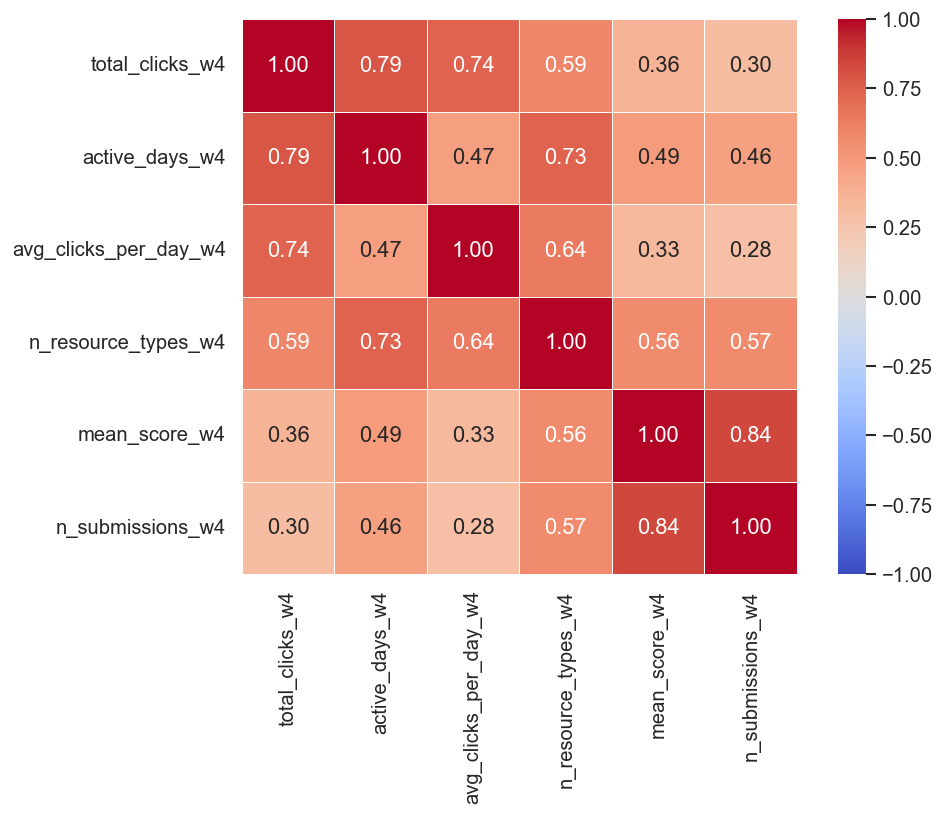

Saved: correlation_heatmap.png


In [168]:
# CORRELATION HEATMAP
import seaborn as sns

vle_cols = ['total_clicks_w4', 'active_days_w4', 'avg_clicks_per_day_w4',
            'n_resource_types_w4', 'mean_score_w4', 'n_submissions_w4']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[vle_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

In [21]:
# CHECK FOR AND REMOVE DUPLICATE ROWS
# We check for duplicates on the COMPOSITE KEY:
#   (id_student, code_module, code_presentation) and keep only the first occurence
n_dups = df.duplicated(subset=grp).sum()
print(f'Duplicate rows found: {n_dups}')

if n_dups > 0:
    df.drop_duplicates(subset=grp, keep='first', inplace=True)
    print(f'  Duplicates removed. New shape: {df.shape}')
else:
    print('  No duplicates found — dataset is clean.')

Duplicate rows found: 0
  No duplicates found — dataset is clean.


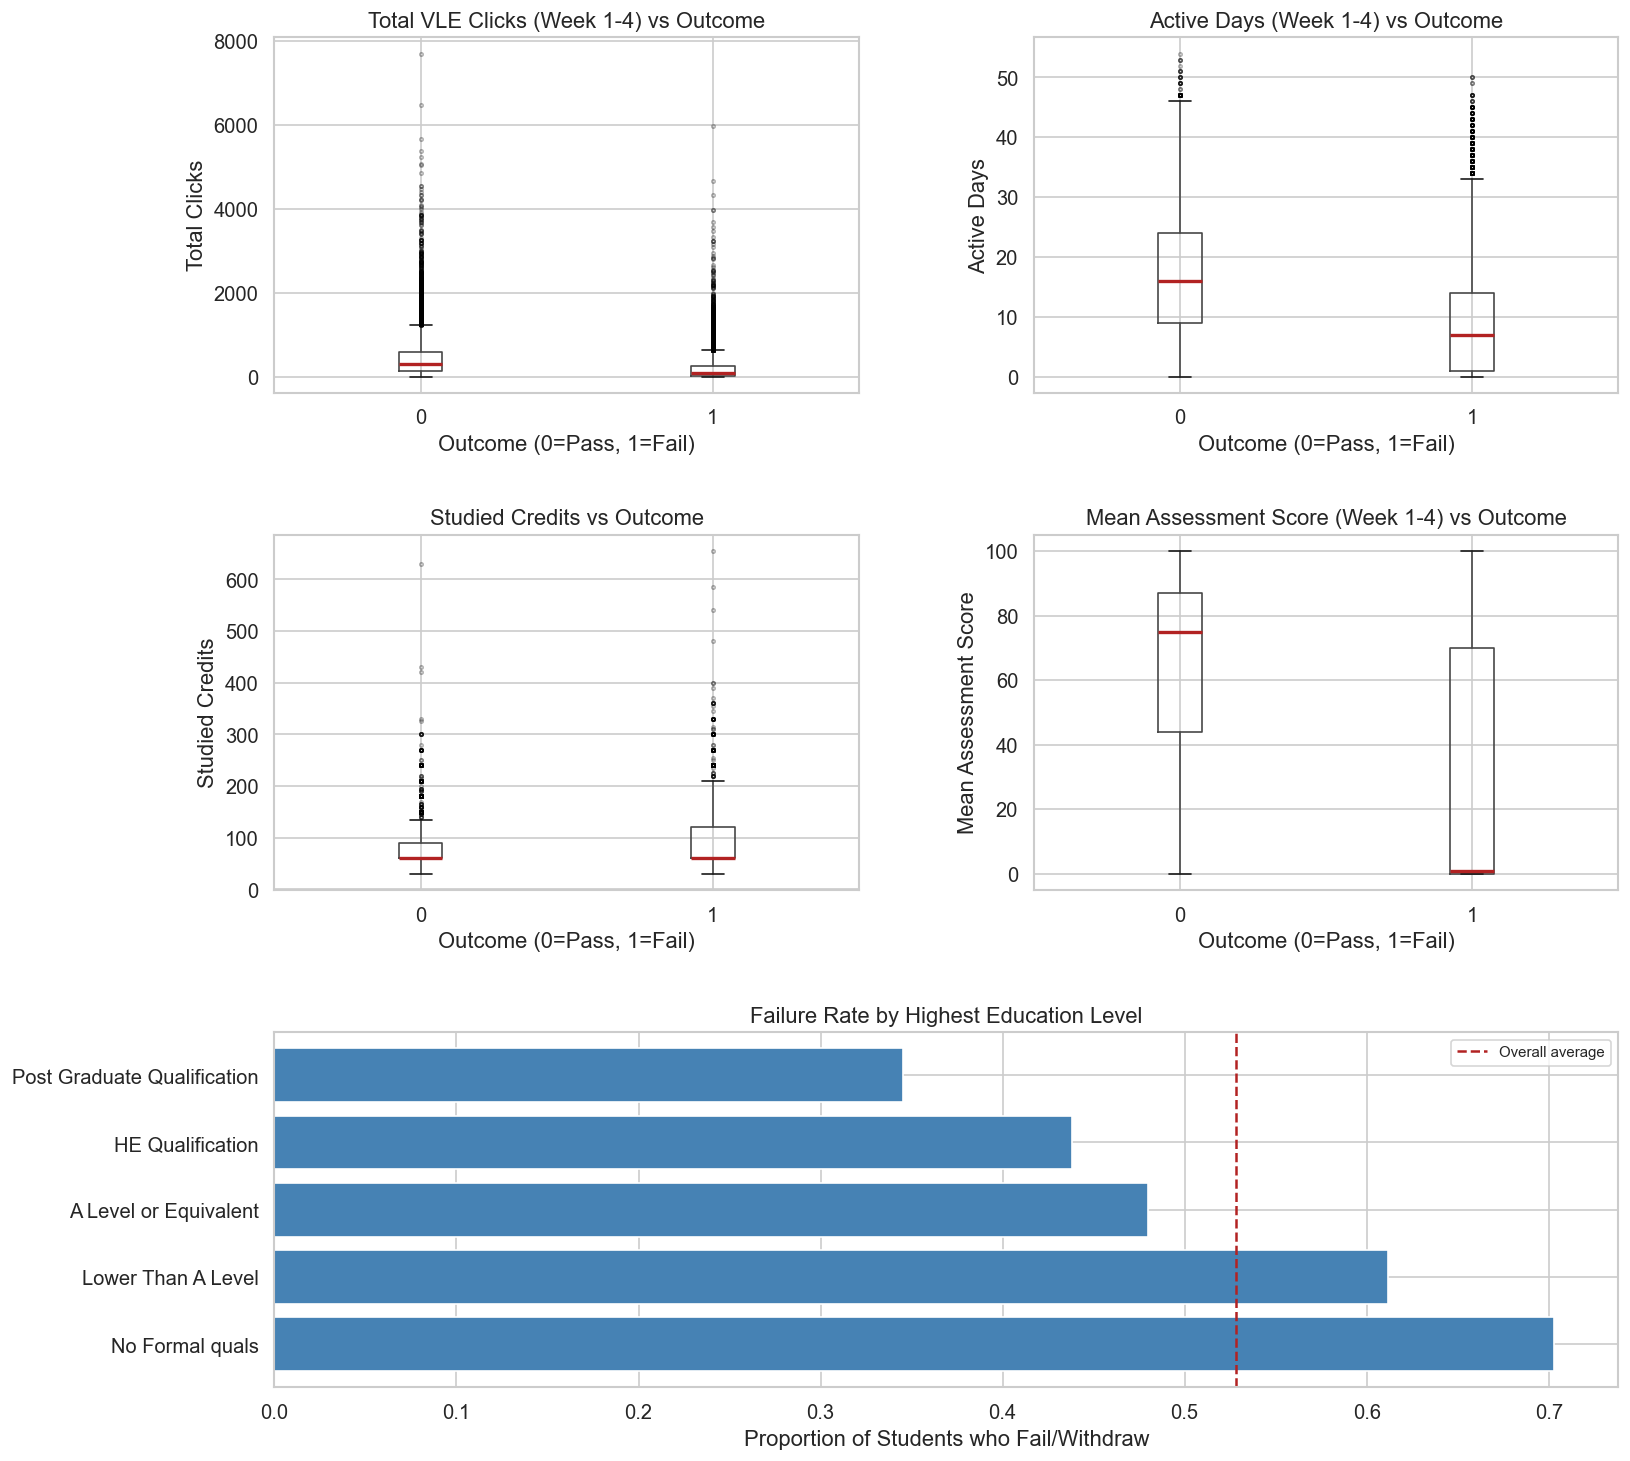

Saved: eda_figures.png


In [160]:
# EXPLORATORY DATA ANALYSIS (EDA) 
fig = plt.figure(figsize=(14, 15))
gs  = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# Chart 1: Total VLE clicks by outcome
# Hypothesis: students who click more are more engaged and less likely to fail
ax = fig.add_subplot(gs[0, 0])
df.boxplot('total_clicks_w4', by='target', ax=ax,
           medianprops=dict(color='firebrick', lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.3))
ax.set_xlabel('Outcome (0=Pass, 1=Fail)')
ax.set_ylabel('Total Clicks')
ax.set_title('Total VLE Clicks (Week 1-4) vs Outcome')

# Chart 2: Active days by outcome 
# Hypothesis: students who log in more consistently are less likely to fail
ax = fig.add_subplot(gs[0, 1])
df.boxplot('active_days_w4', by='target', ax=ax,
           medianprops=dict(color='firebrick', lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.3))
ax.set_xlabel('Outcome (0=Pass, 1=Fail)')
ax.set_ylabel('Active Days')
ax.set_title('Active Days (Week 1-4) vs Outcome')

# Chart 3: Studied credits by outcome
# Hypothesis: students taking more credits may be under more pressure
ax = fig.add_subplot(gs[1, 0])
df.boxplot('studied_credits', by='target', ax=ax,
           medianprops=dict(color='firebrick', lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.3))
ax.set_xlabel('Outcome (0=Pass, 1=Fail)')
ax.set_ylabel('Studied Credits')
ax.set_title('Studied Credits vs Outcome')

# Chart 4: Mean assessment score by outcome 
# Hypothesis: students with higher early assessment scores are less likely to fail
ax = fig.add_subplot(gs[1, 1])
df.boxplot('mean_score_w4', by='target', ax=ax,
           medianprops=dict(color='firebrick', lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.3))
ax.set_xlabel('Outcome (0=Pass, 1=Fail)')
ax.set_ylabel('Mean Assessment Score')
ax.set_title('Mean Assessment Score (Week 1-4) vs Outcome')

# Chart 5: Failure rate by highest education level 
# Hypothesis: students with lower prior education have higher failure rates
ax = fig.add_subplot(gs[2, :])
fail_edu = (
    df.groupby('highest_education')['target']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
ax.barh(fail_edu['highest_education'], fail_edu['target'],
        color='steelblue', edgecolor='white')
ax.axvline(df['target'].mean(), color='firebrick', ls='--', label='Overall average')
ax.set_xlabel('Proportion of Students who Fail/Withdraw')
ax.set_title('Failure Rate by Highest Education Level')
ax.legend(fontsize=9)
plt.suptitle('')  # suppress the default 'by target' suptitle from boxplot
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.savefig('eda_figures.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_figures.png')

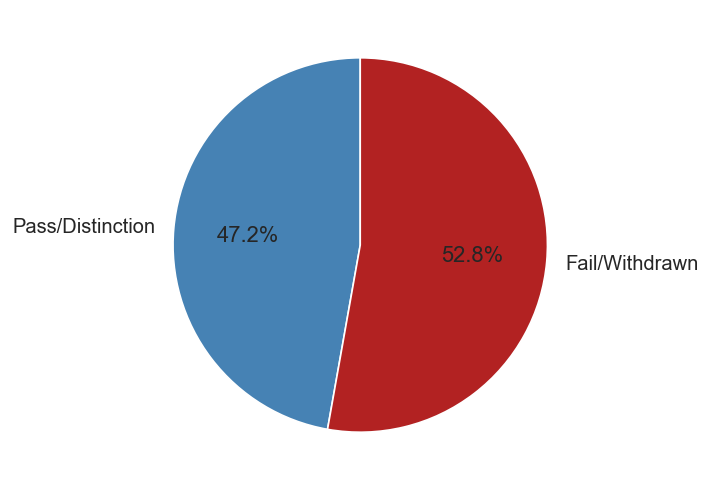

Saved: class_distribution.png


In [164]:
# CLASS DISTRIBUTION PIE CHART
fig, ax = plt.subplots(figsize=(6, 6))

class_counts = df['target'].value_counts().sort_index()

ax.pie(class_counts.values,
       labels=['Pass/Distinction', 'Fail/Withdrawn'],
       colors=['steelblue', 'firebrick'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

In [30]:
# ENCODING CATEGORICAL FEATURES + TRAIN/TEST SPLIT

# SEPARATE FEATURES (X) FROM TARGET (y)
# Drop ID columns and the target.
drop_cols = ['id_student', 'code_module', 'code_presentation', 'target']
X_raw = df.drop(columns=drop_cols) 
y     = df['target'].values         

# ONE-HOT ENCODE CATEGORICAL FEATURES
# Converts text categories into 0/1 columns so the model can read them.
# Example: 'gender' (M/F) becomes gender_F = 1 if female, 0 if male.
# drop_first=True drops one column per feature — e.g. if we already know  gender_F=0, we don't need a separate gender_M column because it's always the opposite.
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True, dtype=float)
print(f'Feature matrix shape after encoding: {X.shape}')

# STRATIFIED 80/20 TRAIN/TEST SPLIT
# We keep 80% of students for training the model and hold out 20% for testing.
# 'stratify=y' ensures BOTH splits have the same pass/fail ratio — without this, the test set could end up with mostly passing students and give us falsely optimistic results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'\nTrain set: {X_train.shape[0]} students  (pos rate: {y_train.mean():.1%})')
print(f'Test  set: {X_test.shape[0]} students  (pos rate: {y_test.mean():.1%})')

Categorical columns to encode: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
Feature matrix shape after encoding: (32593, 56)

Train set: 26074 students  (pos rate: 52.8%)
Test  set: 6519 students  (pos rate: 52.8%)



# PIPELINE 1 — SGD Logistic Regression

In [34]:
# BUILD AND TRAIN PIPELINE 1 using SGD Logistic Regression

pipeline_1 = Pipeline([
    ('scaler', StandardScaler()),        # Rescale all features using StandardScalar (mean=0,SD=1)
    ('clf', SGDClassifier(               # Finds a straight-line boundary that seperates passing from failing students.
        loss='log_loss',                 # logistic regression objective
        penalty='l2',                    # L2 ridge regularisation: penalsies large weights to prevent overfitting.
        alpha=0.0001,                    # regularisation strength
        max_iter=1000,                   # training iterations
        tol=1e-4,                        # stop early if improvement is tiny
        random_state=SEED,
        class_weight='balanced'          # compensate for class imbalance
    ))
])

# Train the model
pipeline_1.fit(X_train, y_train)
print('Pipeline P1 trained successfully!')
print(pipeline_1)

Pipeline P1 trained successfully!
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 SGDClassifier(class_weight='balanced', loss='log_loss',
                               random_state=42, tol=0.0001))])


In [38]:
# CROSS-VALIDATION (Stratified 5-Fold)
# HOW 5-FOLD STRATIFIED CV WORKS:
# 1. Split the TRAINING data into 5 equal folds.
# 2. Train on 4 folds, test on the remaining 1 fold. Repeat 5 times.
# 3. Each fold takes a turn as the test set — every student gets evaluated.
# 4. Average the 5 scores for a robust performance estimate.
# 'Stratified' since each fold maintains the same pass/fail ratio as the overall training set.
# We run this on the TRAINING data only

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = {}

print('Running 5-Fold Cross-Validation on training set...')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(
        pipeline_1, X_train, y_train,
        cv=cv, scoring=metric, n_jobs=-1  # n_jobs=-1 uses all CPU cores
    )
    cv_scores[metric] = scores
    print(f'  {metric:12s}: {scores.mean():.4f}  (+/- {scores.std():.4f})')

Running 5-Fold Cross-Validation on training set...
  accuracy    : 0.7106  (+/- 0.0032)
  precision   : 0.7480  (+/- 0.0077)
  recall      : 0.6818  (+/- 0.0098)
  f1          : 0.7132  (+/- 0.0035)
  roc_auc     : 0.7824  (+/- 0.0047)


In [116]:
# THRESHOLD SWEEP

# The F1 score balances precision and recall, making it the right metric to optimise when we care about both catching failures AND not over-alarming.

y_proba = pipeline_1.predict_proba(X_test)[:, 1]

# Try 200 evenly-spaced threshold values and compute all metrics at each
records = []
for t in np.linspace(0.01, 0.99, 200):
    p = (y_proba >= t).astype(int)  # predict 1 if probability >= threshold
    records.append(dict(
        threshold = t,
        accuracy  = accuracy_score(y_test, p),
        precision = precision_score(y_test, p, zero_division=0),
        recall    = recall_score(y_test, p, zero_division=0),
        f1        = f1_score(y_test, p, zero_division=0)
    ))

thresh_df   = pd.DataFrame(records)
BEST_THRESH = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']  # threshold with highest F1
y_pred      = (y_proba >= BEST_THRESH).astype(int)  # final predictions using best threshold

print(f'Best decision threshold: {BEST_THRESH:.3f}')

Best decision threshold: 0.330


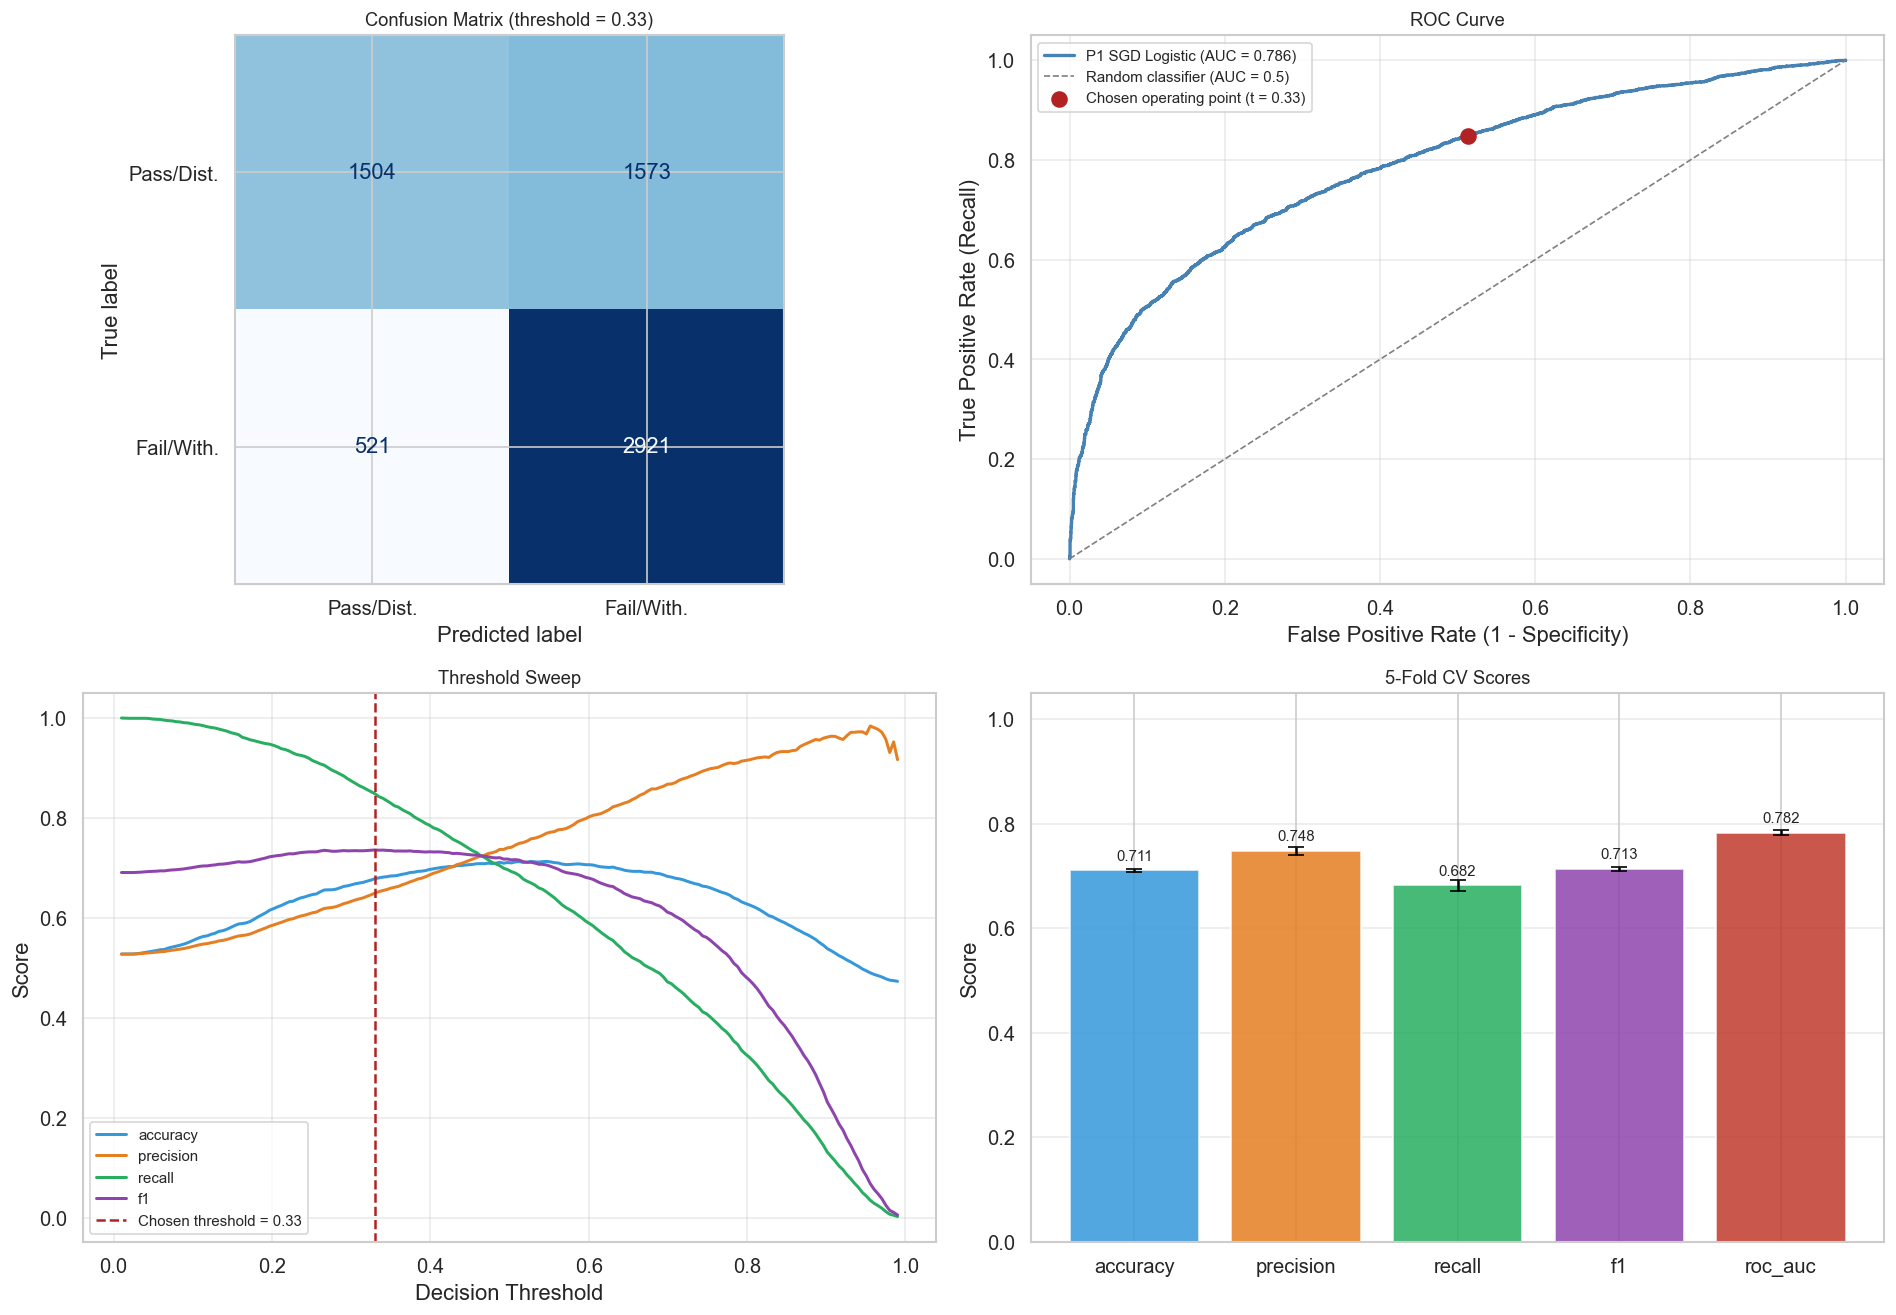

Saved: pipeline1_evaluation.png


In [136]:
# EVALUATION FIGURES
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1: Confusion Matrix 
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Pass/Dist.', 'Fail/With.']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix (threshold = {BEST_THRESH:.2f})', fontsize=11)

# Plot 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'P1 SGD Logistic (AUC = {auc_score:.3f})')
ax2.plot([0, 1], [0, 1], '--', color='grey', lw=1, label='Random classifier (AUC = 0.5)')
op_idx = np.argmin(np.abs(roc_thr - BEST_THRESH))  # find operating point on curve
ax2.scatter([fpr[op_idx]], [tpr[op_idx]], color='firebrick', s=80, zorder=5,
            label=f'Chosen operating point (t = {BEST_THRESH:.2f})')
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('ROC Curve', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Plot 3: Threshold Sweep 
ax3 = fig.add_subplot(gs[1, 0])
for m, c in zip(['accuracy', 'precision', 'recall', 'f1'],
                ['#3498db', '#e67e22', '#27ae60', '#8e44ad']):
    ax3.plot(thresh_df['threshold'], thresh_df[m], label=m, color=c, lw=1.8)
ax3.axvline(BEST_THRESH, color='firebrick', ls='--',
            label=f'Chosen threshold = {BEST_THRESH:.2f}')
ax3.set_xlabel('Decision Threshold')
ax3.set_ylabel('Score')
ax3.set_title('Threshold Sweep', fontsize=11)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)

# Plot 4: CV Bar Chart 
ax4 = fig.add_subplot(gs[1, 1])
mets     = list(cv_scores.keys())
means_v  = [cv_scores[m].mean() for m in mets]
stds_v   = [cv_scores[m].std()  for m in mets]
bars = ax4.bar(mets, means_v,
               color=['#3498db', '#e67e22', '#27ae60', '#8e44ad', '#c0392b'],
               edgecolor='white', alpha=0.85)
ax4.errorbar(mets, means_v, yerr=stds_v, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, means_v):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9)
ax4.set_ylim(0, 1.05); ax4.set_ylabel('Score')
ax4.set_title('5-Fold CV Scores', fontsize=11)
ax4.grid(axis='y', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('pipeline1_evaluation.png', bbox_inches='tight')
plt.show()
print('Saved: pipeline1_evaluation.png')

In [52]:
# FINAL METRICS SUMMARY (Test Set)
print('=' * 60)
print(f'  Pipeline P1 — Final Test-Set Results')
print(f'  Decision threshold: {BEST_THRESH:.3f}')
print('=' * 60)
print(classification_report(
    y_test, y_pred,
    target_names=['Pass/Distinction', 'Fail/Withdrawn']
))
print(f'  AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')

  Pipeline P1 — Final Test-Set Results
  Decision threshold: 0.330
                  precision    recall  f1-score   support

Pass/Distinction       0.74      0.49      0.59      3077
  Fail/Withdrawn       0.65      0.85      0.74      3442

        accuracy                           0.68      6519
       macro avg       0.70      0.67      0.66      6519
    weighted avg       0.69      0.68      0.67      6519

  AUC-ROC  : 0.7858
  Accuracy : 0.6788


In [62]:
# TABLE 4.2: EXPERIMENTS TABLE
auc_score = roc_auc_score(y_test, y_proba)

results_p1 = pd.DataFrame([{
    'Pipeline ID'       : 'P1',
    'Feature set'       : 'Demographics + VLE week-4',
    'Encoding'          : 'One-Hot (drop_first)',
    'Scaling'           : 'StandardScaler',
    'Model'             : 'SGD Logistic Regression (L2)',
    'Eval method'       : '80/20 Stratified Split + 5-Fold Stratified CV',
    'Hyperparameters'   : 'alpha=0.0001, loss=log_loss, class_weight=balanced, max_iter=1000',
    'Seed'              : SEED,
    'Chosen threshold'  : round(BEST_THRESH, 3),
    'Accuracy'          : round(accuracy_score(y_test, y_pred), 4),
    'Precision'         : round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall'            : round(recall_score(y_test, y_pred, zero_division=0), 4),
    'F1'                : round(f1_score(y_test, y_pred, zero_division=0), 4),
    'AUC'               : round(auc_score, 4),
    'CV F1 ': f"{cv_scores['f1'].mean():.3f}+/-{cv_scores['f1'].std():.3f}"
}])

print('Table 4.2 — Pipeline P1 Summary')
display(results_p1.T)

Table 4.2 — Pipeline P1 Summary


,0
Pipeline ID,P1
Feature set,Demographics + VLE week-4
Encoding,One-Hot (drop_first)
Scaling,StandardScaler
Model,SGD Logistic Regression (L2)
Eval method,80/20 Stratified Split + 5-Fold Stratified CV
Hyperparameters,"alpha=0.0001, loss=log_loss, class_weight=bala..."
Seed,42
Chosen threshold,0.33
Accuracy,0.6788


# PIPELINE 2 — Random Forest + GridSearchCV

### What is a Random Forest?
Random Forest uses an approach called Bagging, where instead of training one decision tree, you train hundreds of them — each on a different random sample of the data and a random subset of features. Because every tree sees something slightly different, they all make slightly different mistakes. When you combine them all and take a majority vote, those individual mistakes cancel each other out, giving a much more reliable prediction than any single tree could on its own.

**Key advantages over SGD Logistic Regression:**
- Captures non-linear relationships
- No assumption of a straight-line decision boundary
- Naturally provides feature importance scores
- More robust to outliers

### What is GridSearchCV?
GridSearchCV tries every combination of hyperparameter values in a grid and uses
cross-validation to score each one. It then automatically picks the best combination.
This replaces the manual trial-and-error of P1's fixed hyperparameters.

In [96]:
# BUILD AND TRAIN PIPELINE 2 using Random Forest + GridSearchCV

# Define the base pipeline (scaler + random forest)
# We keep StandardScaler for consistency with P1, even though Random Forest does't need scaling
base_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        random_state=SEED,          # fix the seed so results are reproducible
        class_weight='balanced',    # auto-upweight the minority (Fail) class to handle class imbalance
        n_jobs=-1                  
    ))
])
# Instead of manually guessing good hyperparameter values, we give GridSearchCV a list of options for each parameter and it tries every combination.
param_grid = {
    'clf__n_estimators'      : [100, 200,300 ],  # number of trees in the forest
    'clf__max_depth'         : [None, 10,20 ],   # max depth per tree; None = grow until leaves are pure
    'clf__min_samples_split' : [2, 5,10],       # min samples required to split a node (controls overfitting)
}

total_fits = 3 * 3 * 3 * 5  # 27 combinations x 5-fold CV
# Set up GridSearchCV which trains and evaluates every combination in param_grid.
# For each combination, it uses k-fold cross-validation to get a reliable score.
# StratifiedKFold ensures each fold has the same class ratio as the full dataset.
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = base_rf,
    param_grid = param_grid,
    scoring    = 'f1',       # optimise for F1 
    cv         = cv_inner,
    n_jobs     = -1,
    verbose    = 1,          # print progress as it runs
    refit      = True        # after search, refit best params on full train set
)

print('\nRunning GridSearchCV...')
grid_search.fit(X_train, y_train)

pipeline_2 = grid_search.best_estimator_

print(f'\nBest hyperparameters found:')
for k, v in grid_search.best_params_.items():
    print(f'  {k.replace("clf__","")}: {v}')
print(f'\nBest CV F1 score: {grid_search.best_score_:.4f}')
print('Pipeline P2 ready!')


Running GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best hyperparameters found:
  max_depth: 20
  min_samples_split: 2
  n_estimators: 300

Best CV F1 score: 0.7404
Pipeline P2 ready!


In [98]:
# GRIDSEARCH RESULTS TABLE
gs_results = pd.DataFrame(grid_search.cv_results_)
gs_top = (
    gs_results[[
        'param_clf__n_estimators',
        'param_clf__max_depth',
        'param_clf__min_samples_split',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]]
    .sort_values('rank_test_score')
    .head(10)
)
gs_top.columns = ['n_estimators', 'max_depth', 'min_samples_split',
                   'mean F1 (CV)', 'std F1', 'rank']

print('Top 10 GridSearch results (ranked by cross-validated F1):')
display(gs_top)

Top 10 GridSearch results (ranked by cross-validated F1):


,n_estimators,max_depth,min_samples_split,mean F1 (CV),std F1,rank
20,300,20,2,0.740352,0.006214,1
4,200,None,5,0.740308,0.005965,2
5,300,None,5,0.740220,0.006152,3
2,300,None,2,0.739624,0.006313,4
23,300,20,5,0.739232,0.007342,5
8,300,None,10,0.739177,0.006907,6
19,200,20,2,0.738737,0.006139,7
1,200,None,2,0.738657,0.006676,8
18,100,20,2,0.738489,0.006868,9
22,200,20,5,0.738317,0.007650,10


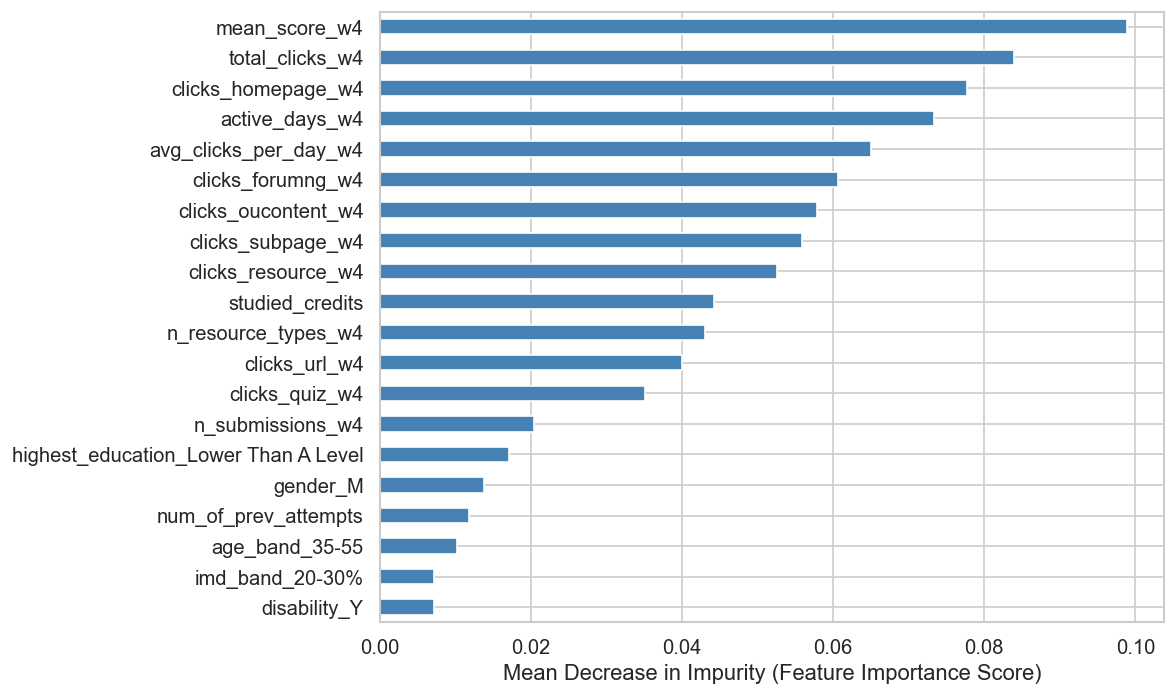

Saved: feature_importance_p2.png

Top 5 most important features:
  mean_score_w4: 0.0989
  total_clicks_w4: 0.0839
  clicks_homepage_w4: 0.0777
  active_days_w4: 0.0734
  avg_clicks_per_day_w4: 0.0650


In [146]:
# FEATURE IMPORTANCE 
# Each time a tree makes a split, it picks the feature that best separates passing from failing students
rf_model      = pipeline_2.named_steps['clf']  # extract the RandomForest from the pipeline
importances   = rf_model.feature_importances_  # array of importance scores (MDI)
feature_names = X.columns.tolist()
# Pair each feature name with its importance score and sort highest to lowest
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Mean Decrease in Impurity (Feature Importance Score)')
plt.tight_layout()
plt.savefig('feature_importance_p2.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance_p2.png')
print(f'\nTop 5 most important features:')
for feat, imp in feat_imp.head(5).items():
    print(f'  {feat}: {imp:.4f}')

In [102]:
# CROSS-VALIDATION ON PIPELINE 2 (outer CV)
# Same 5-fold stratified CV setup as Pipeline 1, applied to P2's best model.
cv_outer  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores_p2 = {}

print('Running outer 5-Fold CV on Pipeline 2...')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(
        pipeline_2, X_train, y_train,
        cv=cv_outer, scoring=metric, n_jobs=-1
    )
    cv_scores_p2[metric] = scores
    print(f'  {metric:12s}: {scores.mean():.4f}  (+/- {scores.std():.4f})')

Running outer 5-Fold CV on Pipeline 2...
  accuracy    : 0.7414  (+/- 0.0047)
  precision   : 0.7878  (+/- 0.0051)
  recall      : 0.6984  (+/- 0.0112)
  f1          : 0.7404  (+/- 0.0062)
  roc_auc     : 0.8230  (+/- 0.0043)


In [122]:
# THRESHOLD SWEEP
# Sweep all thresholds, pick the one with best F1.
# P2's probabilities may be better calibrated than P1's because Random Forest naturally spreads probability estimates across the full [0,1] range.

y_proba_p2 = pipeline_2.predict_proba(X_test)[:, 1]  # probability of Fail/Withdrawn

records = []
for t in np.linspace(0.01, 0.99, 200):
    p = (y_proba_p2 >= t).astype(int)
    records.append(dict(
        threshold = t,
        accuracy  = accuracy_score(y_test, p),
        precision = precision_score(y_test, p, zero_division=0),
        recall    = recall_score(y_test, p, zero_division=0),
        f1        = f1_score(y_test, p, zero_division=0)
    ))

thresh_df_p2   = pd.DataFrame(records)
BEST_THRESH_P2 = thresh_df_p2.loc[thresh_df_p2['f1'].idxmax(), 'threshold']
y_pred_p2      = (y_proba_p2 >= BEST_THRESH_P2).astype(int)

print(f'Best decision threshold for P2: {BEST_THRESH_P2:.3f}')

Best decision threshold for P2: 0.419


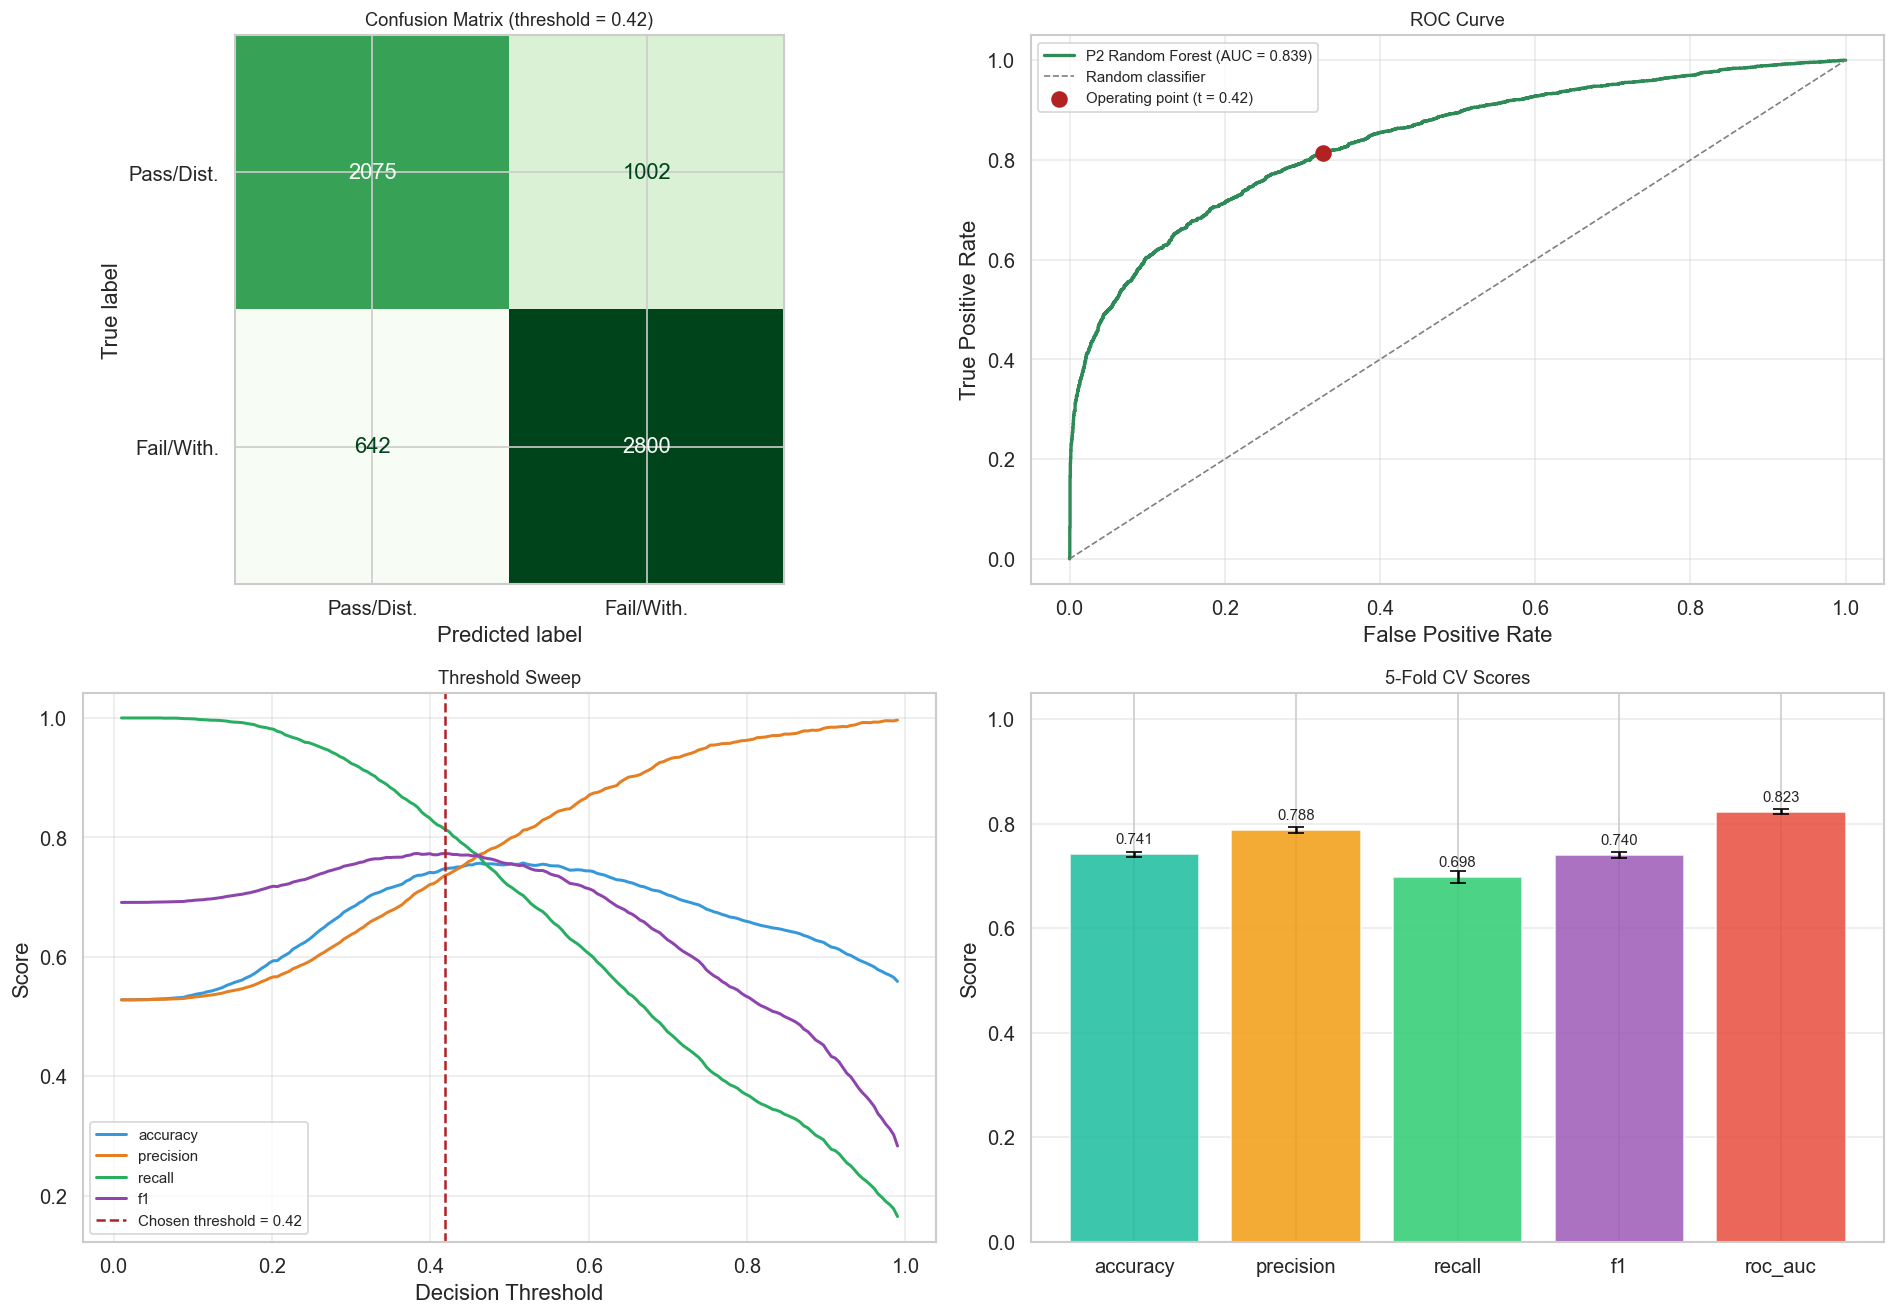

Saved: pipeline2_evaluation.png


In [138]:
#  EVALUATION FIGURES (Figure 3.3 — Pipeline 2)

fig = plt.figure(figsize=(16, 12))
gs_fig = gridspec.GridSpec(2, 2, figure=fig)

# Confusion Matrix
ax1 = fig.add_subplot(gs_fig[0, 0])
cm2 = confusion_matrix(y_test, y_pred_p2)
ConfusionMatrixDisplay(cm2, display_labels=['Pass/Dist.', 'Fail/With.']).plot(
    ax=ax1, colorbar=False, cmap='Greens')
ax1.set_title(f'Confusion Matrix (threshold = {BEST_THRESH_P2:.2f})', fontsize=11)

# ROC Curve 
ax2 = fig.add_subplot(gs_fig[0, 1])
fpr2, tpr2, roc_thr2 = roc_curve(y_test, y_proba_p2)
auc_score_p2 = roc_auc_score(y_test, y_proba_p2)
ax2.plot(fpr2, tpr2, color='seagreen', lw=2,
         label=f'P2 Random Forest (AUC = {auc_score_p2:.3f})')
ax2.plot([0, 1], [0, 1], '--', color='grey', lw=1, label='Random classifier')
op_idx2 = np.argmin(np.abs(roc_thr2 - BEST_THRESH_P2))
ax2.scatter([fpr2[op_idx2]], [tpr2[op_idx2]], color='firebrick', s=80, zorder=5,
            label=f'Operating point (t = {BEST_THRESH_P2:.2f})')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Threshold Sweep 
ax3 = fig.add_subplot(gs_fig[1, 0])
for m, c in zip(['accuracy', 'precision', 'recall', 'f1'],
                ['#3498db', '#e67e22', '#27ae60', '#8e44ad']):
    ax3.plot(thresh_df_p2['threshold'], thresh_df_p2[m], label=m, color=c, lw=1.8)
ax3.axvline(BEST_THRESH_P2, color='firebrick', ls='--',
            label=f'Chosen threshold = {BEST_THRESH_P2:.2f}')
ax3.set_xlabel('Decision Threshold')
ax3.set_ylabel('Score')
ax3.set_title('Threshold Sweep', fontsize=11)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)

# CV Bar Chart
ax4 = fig.add_subplot(gs_fig[1, 1])
mets     = list(cv_scores_p2.keys())
means_v2 = [cv_scores_p2[m].mean() for m in mets]
stds_v2  = [cv_scores_p2[m].std()  for m in mets]
bars = ax4.bar(mets, means_v2,
               color=['#1abc9c', '#f39c12', '#2ecc71', '#9b59b6', '#e74c3c'],
               edgecolor='white', alpha=0.85)
ax4.errorbar(mets, means_v2, yerr=stds_v2, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, means_v2):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=9)
ax4.set_ylim(0, 1.05); ax4.set_ylabel('Score')
ax4.set_title('5-Fold CV Scores', fontsize=11)
ax4.grid(axis='y', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('pipeline2_evaluation.png', bbox_inches='tight')
plt.show()
print('Saved: pipeline2_evaluation.png')

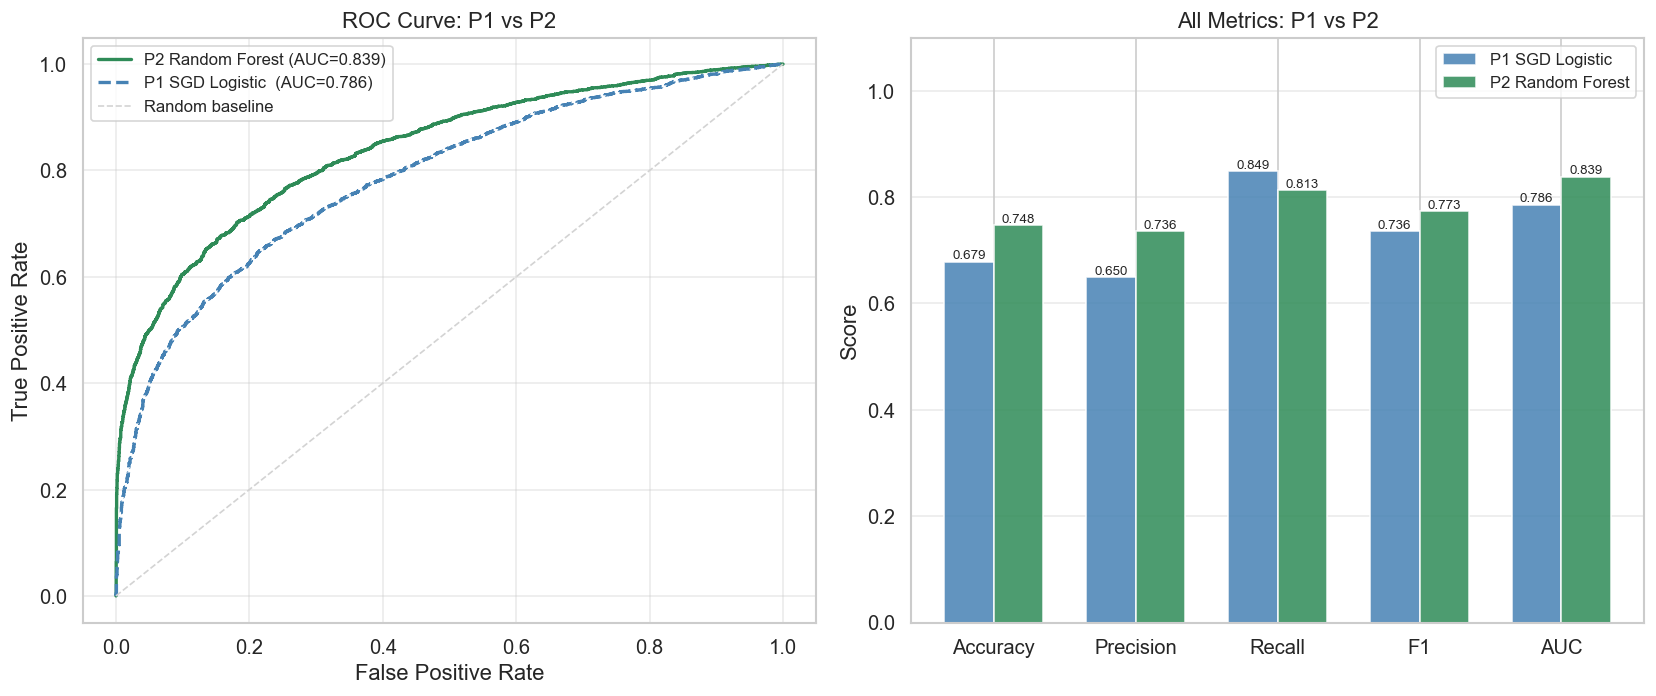

Saved: pipeline_comparison.png

Quick comparison summary:
  Metric           P1 SGD      P2 RF     Winner
----------------------------------------------
  Accuracy         0.6788     0.7478         P2
  Precision        0.6500     0.7365         P2
  Recall           0.8486     0.8135         P1
  F1               0.7361     0.7731         P2
  AUC              0.7858     0.8386         P2


In [140]:

# P1 vs P2 HEAD-TO-HEAD COMPARISON 
# Gather P1 values
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
auc_p1        = roc_auc_score(y_test, y_proba)
p1_vals = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
    auc_p1
]

# Gather P2 values
p2_vals = [
    accuracy_score(y_test, y_pred_p2),
    precision_score(y_test, y_pred_p2, zero_division=0),
    recall_score(y_test, y_pred_p2, zero_division=0),
    f1_score(y_test, y_pred_p2, zero_division=0),
    auc_score_p2
]

metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x_pos = np.arange(len(metric_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves overlaid
ax = axes[0]
ax.plot(fpr2, tpr2, color='seagreen', lw=2,
        label=f'P2 Random Forest (AUC={auc_score_p2:.3f})')
ax.plot(fpr1, tpr1, color='steelblue', lw=2, ls='--',
        label=f'P1 SGD Logistic  (AUC={auc_p1:.3f})')
ax.plot([0,1],[0,1],'--', color='lightgrey', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: P1 vs P2')
ax.legend(fontsize=10); ax.grid(True, alpha=0.4)

# Bar chart of all metrics side by side
ax = axes[1]
bars1 = ax.bar(x_pos - width/2, p1_vals, width,
               label='P1 SGD Logistic', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x_pos + width/2, p2_vals, width,
               label='P2 Random Forest', color='seagreen', alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, p1_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, p2_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('All Metrics: P1 vs P2')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('pipeline_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: pipeline_comparison.png')

# Summary table
print('\nQuick comparison summary:')
print(f'  {"Metric":<12} {"P1 SGD":>10} {"P2 RF":>10} {"Winner":>10}')
print('-' * 46)
for label, v1, v2 in zip(metric_labels, p1_vals, p2_vals):
    winner = 'P2' if v2 > v1 else ('P1' if v1 > v2 else 'Tie')
    print(f'  {label:<12} {v1:>10.4f} {v2:>10.4f} {winner:>10}')

In [110]:
# FINAL METRICS SUMMARY (Test Set)

print('=' * 60)
print(f'  Pipeline P2 — Final Test-Set Results')
print(f'  Decision threshold: {BEST_THRESH_P2:.3f}')
print('=' * 60)
print(classification_report(
    y_test, y_pred_p2,
    target_names=['Pass/Distinction', 'Fail/Withdrawn']
))
print(f'  AUC-ROC  : {auc_score_p2:.4f}')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_p2):.4f}')

  Pipeline P2 — Final Test-Set Results
  Decision threshold: 0.419
                  precision    recall  f1-score   support

Pass/Distinction       0.76      0.67      0.72      3077
  Fail/Withdrawn       0.74      0.81      0.77      3442

        accuracy                           0.75      6519
       macro avg       0.75      0.74      0.74      6519
    weighted avg       0.75      0.75      0.75      6519

  AUC-ROC  : 0.8386
  Accuracy : 0.7478


In [144]:
# TABLE 4.2: COMBINED EXPERIMENTS TABLE (P1 + P2)
best_params = grid_search.best_params_
hparam_str  = (f"n_estimators={best_params['clf__n_estimators']}, "
               f"max_depth={best_params['clf__max_depth']}, "
               f"min_samples_split={best_params['clf__min_samples_split']}, "
               f"class_weight=balanced")

results_p2 = pd.DataFrame([{
    'Pipeline ID'       : 'P2',
    'Feature set'       : 'Demographics + VLE week-4',
    'Encoding'          : 'One-Hot (drop_first)',
    'Scaling'           : 'StandardScaler',
    'Model'             : 'Random Forest (GridSearchCV tuned)',
    'Eval method'       : '80/20 Split + GridSearchCV (inner 5-Fold) + outer 5-Fold CV',
    'Hyperparameters'   : hparam_str,
    'Seed'              : SEED,
    'Chosen threshold'  : round(BEST_THRESH_P2, 3),
    'Accuracy'          : round(accuracy_score(y_test, y_pred_p2), 4),
    'Precision'         : round(precision_score(y_test, y_pred_p2, zero_division=0), 4),
    'Recall'            : round(recall_score(y_test, y_pred_p2, zero_division=0), 4),
    'F1'                : round(f1_score(y_test, y_pred_p2, zero_division=0), 4),
    'AUC'               : round(auc_score_p2, 4),
    'CV F1 (mean+/-std)': f"{cv_scores_p2['f1'].mean():.3f}+/-{cv_scores_p2['f1'].std():.3f}"
}])

combined = pd.concat([results_p1, results_p2], ignore_index=True)
print('Table 4.2 — Combined Pipeline Comparison')
display(combined.T)
print(hparam_str)
combined.to_csv('table_4_2_combined.csv', index=False)
print('Saved: table_4_2_combined.csv')

Table 4.2 — Combined Pipeline Comparison


,0,1
Pipeline ID,P1,P2
Feature set,Demographics + VLE week-4,Demographics + VLE week-4
Encoding,One-Hot (drop_first),One-Hot (drop_first)
Scaling,StandardScaler,StandardScaler
Model,SGD Logistic Regression (L2),Random Forest (GridSearchCV tuned)
Eval method,80/20 Stratified Split + 5-Fold Stratified CV,80/20 Split + GridSearchCV (inner 5-Fold) + ou...
Hyperparameters,"alpha=0.0001, loss=log_loss, class_weight=bala...","n_estimators=300, max_depth=20, min_samples_sp..."
Seed,42,42
Chosen threshold,0.33,0.419
Accuracy,0.6788,0.7478


n_estimators=300, max_depth=20, min_samples_split=2, class_weight=balanced
Saved: table_4_2_combined.csv


In [114]:
# TABLE 4.1: FEATURE TABLE

records = []
for col in X_raw.columns:
    dtype  = 'cat' if col in cat_cols else 'num'
    source = 'studentInfo.csv' if col in demo_cols else 'studentVle.csv / vle.csv'
    records.append({
        'Feature'       : col,
        'Source CSV'    : source,
        'Data type'     : dtype,
        'Week avail.'   : '4' if '_w4' in col else '2/4/6/8',
        'Missing count' : 0,              # 0 after imputation in Cell 5
        'Outlier count' : outlier_summary.get(col, 0),
        'Dup count'     : 0,              # handled at row level in Cell 7
        'Leakage risk'  : 'None'          # all features use week-4 data only
    })

feat_table = pd.DataFrame(records)
display(feat_table)

feat_table.to_csv('table_4_1_features.csv', index=False)
print('Saved: table_4_1_features.csv')

,Feature,Source CSV,Data type,Week avail.,Missing count,Outlier count,Dup count,Leakage risk
0,gender,studentInfo.csv,cat,2/4/6/8,0,0,0,None
1,region,studentInfo.csv,cat,2/4/6/8,0,0,0,None
2,highest_education,studentInfo.csv,cat,2/4/6/8,0,0,0,None
3,imd_band,studentInfo.csv,cat,2/4/6/8,0,0,0,None
4,age_band,studentInfo.csv,cat,2/4/6/8,0,0,0,None
5,num_of_prev_attempts,studentInfo.csv,num,2/4/6/8,0,0,0,None
6,studied_credits,studentInfo.csv,num,2/4/6/8,0,0,0,None
7,disability,studentInfo.csv,cat,2/4/6/8,0,0,0,None
8,total_clicks_w4,studentVle.csv / vle.csv,num,4,0,2019,0,None
9,active_days_w4,studentVle.csv / vle.csv,num,4,0,420,0,None


Saved: table_4_1_features.csv
